In [1]:
import sys
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
if not abs_path in sys.path:
    sys.path+=[abs_path]
print(sys.path)

['/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/opt/conda/lib/python3.10/site-packages', '/workspace/pytorch3d', '/source/sihun/NFS']


In [2]:
import numpy as np
import torch

%load_ext autoreload
%autoreload 2
from utils.exp_utils import *
from utils.remesh_utils import ICT_face_model, compute_MVC, apply_MVC_weights_batch

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
  Cloning https://github.com/chacorp/matplotrender.git to /tmp/pip-req-build-9f8j00ua
  Running command git clone --filter=blob:none --quiet https://github.com/chacorp/matplotrender.git /tmp/pip-req-build-9f8j00ua
  Resolved https://github.com/chacorp/matplotrender.git to commit 8342de8c0aba97617700f6aa0ce9e2979b7c087a
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'matplotrender' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'matplotrender'. Discussion can be found at https://github.com/pypa/pip/issues/6334

In [3]:

# Normalize vertices to homogeneous coordinates
def normalize_homogeneous(V):
    return np.concatenate([V, np.ones((V.shape[0], 1))], axis=1)

pca_holder = PCA_holder(
    "/data/sihun/VOCA-COMA/VOCASET/train/FaceTalk_170915_00223_TA_pca.npz"
    # "/data/sihun/VOCA-COMA/COMA/train/FaceTalk_170915_00223_TA_pca.npz"
)
flame_std = np.load(
    "/source/sihun/NFS/utils/voca/standardization.npy",
    allow_pickle=True
).item()


align_mat = np.load("/source/sihun/NFS/utils/voca/align.npy")
align_mat

array([[10.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  , 10.  ,  0.  ,  0.11],
       [ 0.  ,  0.  , 10.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  1.  ]])

15
[-1.16691402 -1.7535233  -1.58045182] [1.16365977 1.49602881 0.79059122]


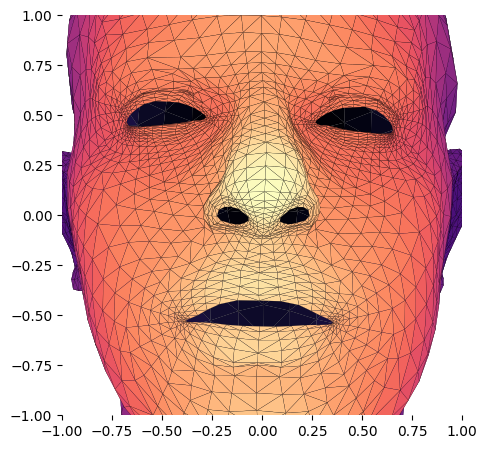

In [4]:
# asd = pca_holder.sample_from_pca(scale=1.0)
asd = pca_holder.sample_from_pca_one_axis(scale=1.0, select=-1,verbose=True)
faces = flame_std['new_f']


V = normalize_homogeneous(asd)
print(asd.min(0), asd.max(0))
# V = V @ align_mat.T

SIZE=4
model = yrotate(0)
view  = translate(0, 0, -3.5)
proj  = perspective(25, 1, 1, 100)
MVP   = proj @ view @ model
V = V @ MVP.T
V /= V[:, 3].reshape(-1, 1)

VF = V[faces]
T = VF[:, :, :2]
Z = -VF[:, :, 2].mean(axis=1)
Z = (Z - Z.min()) / (Z.max() - Z.min())
C = plt.get_cmap("magma")(Z)
I = np.argsort(Z)

T, C = T[I, :], C[I, :]
fig = plt.figure(figsize=(SIZE, SIZE))
ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
ax.add_collection(collection)
plt.show()

In [50]:
pca_holder.components_.shape

(100, 10575)

In [12]:
asd.shape
faces.shape

(6910, 3)

# test cage

In [43]:
from easydict import EasyDict

## dummy
src_mesh = EasyDict()
src_mesh.v = asd
src_mesh.f = faces

# large cube
control_mesh = EasyDict()
# quad mesh
control_mesh.f = np.array([
    [0,2,3,1],
    [0,1,5,4],
    [1,3,7,5],
    [3,2,6,7],
    [2,0,4,6],
    [5,7,6,4],
])
# make triangle great again 
control_mesh.f = control_mesh.f[:,[[3,2,1],[3,1,0]]].reshape(-1, 3)

control_mesh.v = np.zeros((8,3))

## X, Y, Z
control_mesh.v[0] = src_mesh.v.max(0)
control_mesh.v[1,0], control_mesh.v[1,1], control_mesh.v[1,2] = src_mesh.v.max(0)[0], src_mesh.v.max(0)[1], src_mesh.v.min(0)[2]
control_mesh.v[2,0], control_mesh.v[2,1], control_mesh.v[2,2] = src_mesh.v.min(0)[0], src_mesh.v.max(0)[1], src_mesh.v.max(0)[2]
control_mesh.v[3,0], control_mesh.v[3,1], control_mesh.v[3,2] = src_mesh.v.min(0)[0], src_mesh.v.max(0)[1], src_mesh.v.min(0)[2]

control_mesh.v[4,0], control_mesh.v[4,1], control_mesh.v[4,2] = src_mesh.v.max(0)[0], src_mesh.v.min(0)[1], src_mesh.v.max(0)[2]
control_mesh.v[5,0], control_mesh.v[5,1], control_mesh.v[5,2] = src_mesh.v.max(0)[0], src_mesh.v.min(0)[1], src_mesh.v.min(0)[2]
control_mesh.v[6,0], control_mesh.v[6,1], control_mesh.v[6,2] = src_mesh.v.min(0)[0], src_mesh.v.min(0)[1], src_mesh.v.max(0)[2]
control_mesh.v[7] = src_mesh.v.min(0)

# control_mesh.v[:,1]=control_mesh.v[:,1]*1.05
control_mesh.v=control_mesh.v*1.1


control_mesh_v2 = control_mesh.v.copy()
control_mesh_v2[0:4, 0] = control_mesh_v2[0:4, 0]+0.8
control_mesh_v2[0:4] = control_mesh_v2[0:4] @ zrotate(30)[:3,:3]

control_mesh_v3 = control_mesh.v.copy()
control_mesh_v3[0:4, 1] = control_mesh_v3[0:4, 1]+0.8

control_mesh_v4 = control_mesh.v.copy()
control_mesh_v4[0:4, 0] = control_mesh_v4[0:4, 0]-0.4
control_mesh_v4[0:4, 1] = control_mesh_v4[0:4, 1]-0.5
control_mesh_v4[0:4]=control_mesh_v4[0:4] @ yrotate(60)[:3,:3]

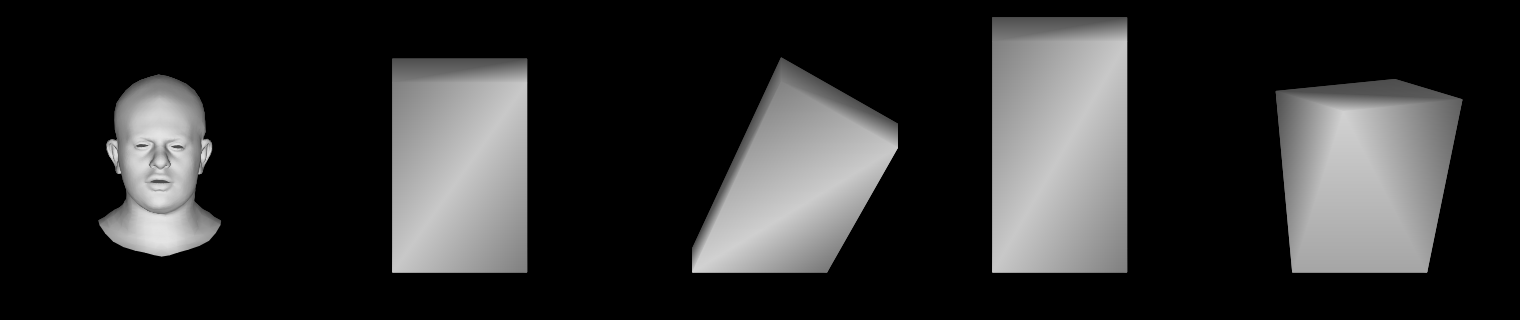

In [44]:

SIZE = 3
mesh_scale = .35

# v_list=[ src_mesh.v, control_mesh.v, control_mesh_v2, control_mesh_v3, control_mesh_v4, np.r_[src_mesh.v, control_mesh.v]]
# f_list=[ src_mesh.f, control_mesh.f, control_mesh.f, control_mesh.f, control_mesh.f, np.r_[src_mesh.f, control_mesh.f+src_mesh.f.max()+1]]
v_list=[ src_mesh.v, control_mesh.v, control_mesh_v2, control_mesh_v3, control_mesh_v4]
f_list=[ src_mesh.f, control_mesh.f, control_mesh.f, control_mesh.f, control_mesh.f]

# xyz Euler angle to rotate the mesh
rot_list=[ [10,0,0] ]*len(v_list)

plot_mesh_gouraud(v_list, f_list, 
                     # is_diff=True, diff_base=src_mesh.v, #diff_revert=True,
                     mesh_scale=mesh_scale,
                     rot_list=rot_list, size=SIZE, mode='shade')

In [45]:
mvc = compute_MVC(
    torch.tensor(asd), torch.tensor(control_mesh.v), torch.tensor(control_mesh.f).long()
)
print(mvc.shape)

torch.Size([3525, 12, 3])


In [46]:
# apply_MVC_weights, 
deformed_cages = torch.vstack([
    torch.tensor(control_mesh.v)[None],
    torch.tensor(control_mesh_v2)[None],
    torch.tensor(control_mesh_v3)[None],
    torch.tensor(control_mesh_v4)[None]
])
print(deformed_cages.shape)


torch.Size([4, 8, 3])


In [47]:
new_asd = apply_MVC_weights_batch(mvc, torch.tensor(control_mesh.f).long(), deformed_cages)

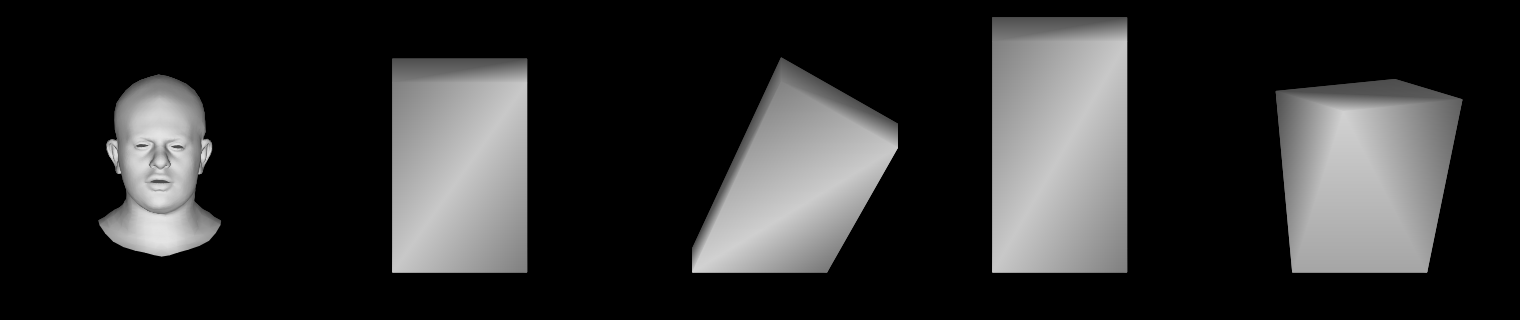

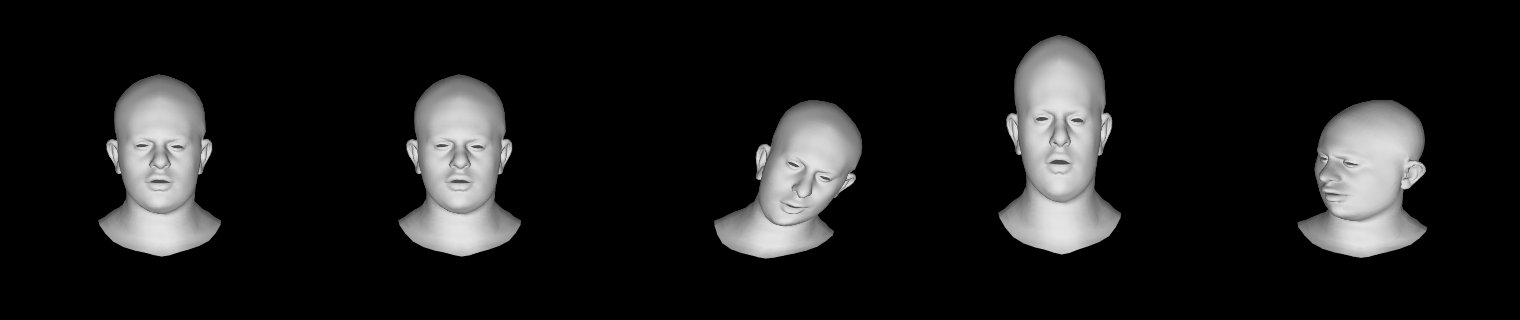

In [48]:
SIZE = 3
mesh_scale = .35

# v_list=[ src_mesh.v, new_v, control_mesh.v, control_mesh.v*1.2-control_mesh_v12_mean+control_mesh_v_mean]
v_list2=[ 
    asd,
    new_asd[0],
    new_asd[1],
    new_asd[2],
    new_asd[3],
]
f_list2=[
    src_mesh.f,
    src_mesh.f,
    src_mesh.f,
    src_mesh.f,
    src_mesh.f,
]

# xyz Euler angle to rotate the mesh
rot_list=[ [10,0,0] ]*len(v_list)



plot_mesh_gouraud(v_list, f_list, 
                     # is_diff=True, diff_base=src_mesh.v, #diff_revert=True,
                     mesh_scale=mesh_scale,
                     rot_list=rot_list, size=SIZE, mode='shade')

plot_mesh_gouraud(v_list2, f_list2, 
                     # is_diff=True, diff_base=src_mesh.v, #diff_revert=True,
                     mesh_scale=mesh_scale,
                     rot_list=rot_list, size=SIZE, mode='shade')

[-1.16698568 -1.72956345 -1.58434907] [1.16065956 1.49809555 0.78881018]


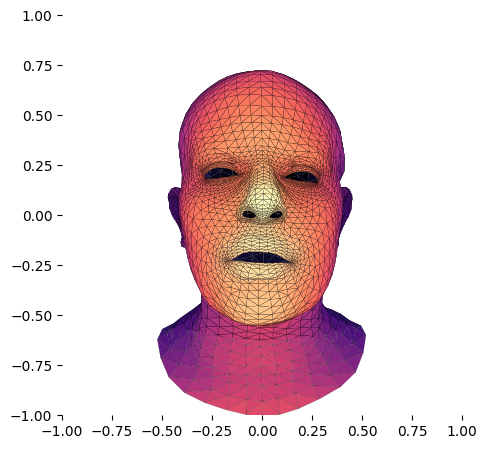

In [8]:
with open("/data/sihun/VOCA-COMA/voca_templates.pkl",'rb') as f:
    asd_f = pickle.load(f)
faces = asd_f['face']
SIZE=4

pca_holder = PCA_holder(
"/data/sihun/VOCA-COMA/VOCASET/train/FaceTalk_170915_00223_TA_pca.npz"
)
asd = pca_holder.sample_from_pca(scale=1.0)
# print()
# faces = flame_std['new_f']

V = normalize_homogeneous(asd)
print(asd.min(0), asd.max(0))
# V = V @ align_mat.T

model = yrotate(0)
view  = translate(0, 0, -3.5)
proj  = perspective(55, 1, 1, 100)
MVP   = proj @ view @ model
V = V @ MVP.T
V /= V[:, 3].reshape(-1, 1)

VF = V[faces]
T = VF[:, :, :2]
Z = -VF[:, :, 2].mean(axis=1)
Z = (Z - Z.min()) / (Z.max() - Z.min())
C = plt.get_cmap("magma")(Z)
I = np.argsort(Z)

T, C = T[I, :], C[I, :]
fig = plt.figure(figsize=(SIZE, SIZE))
ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
ax.add_collection(collection)
plt.show()

In [17]:
asd_f

{'FaceTalk_170904_00128_TA': array([[ 0.53541698, -0.01343633, -0.51542975],
        [ 0.57030972, -0.02358274, -0.50061911],
        [ 0.57718363, -0.00555624, -0.49567744],
        ...,
        [ 0.13412645, -0.19174384,  0.55754729],
        [ 0.25302572, -0.35074178,  0.43819737],
        [ 0.22234043, -0.37385985,  0.46886824]]),
 'FaceTalk_170811_03275_TA': array([[ 0.55631228, -0.01006974, -0.51775005],
        [ 0.59264265, -0.01979834, -0.50413702],
        [ 0.59812378, -0.00398726, -0.49879137],
        ...,
        [ 0.12762338, -0.20082151,  0.55701688],
        [ 0.24622442, -0.39014749,  0.43253455],
        [ 0.2211564 , -0.42280607,  0.45468021]]),
 'FaceTalk_170728_03272_TA': array([[ 0.63482679, -0.01770596, -0.58239184],
        [ 0.67166403, -0.02845206, -0.56767605],
        [ 0.6773816 , -0.0116129 , -0.56237768],
        ...,
        [ 0.15796427, -0.2238062 ,  0.60009602],
        [ 0.27638998, -0.41929882,  0.49407542],
        [ 0.23796814, -0.4476665 ,  0.52

[-1.152973   -2.10862345 -1.65465515] [1.28090604 1.66329228 0.74408604]


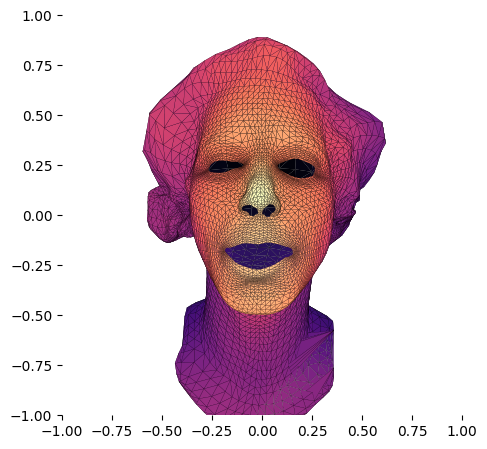

In [23]:
with open("/data/sihun/multiface_align/mf_templates.pkl",'rb') as f:
    asd_f = pickle.load(f)
# _std = np.load("../utils/mf/standardization.npy", allow_pickle=True).item()
# _std

pca_holder = PCA_holder(
#     "/data/sihun/multiface_align/ROM/train/vertices_npy/m--20180426--0000--002643814--GHS_pca.npz"
#     '/data/sihun/multiface_align/ROM/val/vertices_npy/m--20190529--1300--002421669--GHS_pca.npz'
    '/data/sihun/multiface_align/SEN/val/vertices_npy/m--20190529--1300--002421669--GHS_pca.npz'
)

asd = pca_holder.sample_from_pca(scale=1.0)
faces = asd_f['face']
# faces = _std["new_f"]

# print()
V = normalize_homogeneous(asd) 
print(asd.min(0), asd.max(0))
# V = V @ align_mat.T
SIZE=4

model = yrotate(0)
view  = translate(0, 0, -3.5)
proj  = perspective(55, 1, 1, 100)
MVP   = proj @ view @ model
V = V @ MVP.T
V /= V[:, 3].reshape(-1, 1)

VF = V[faces]
T = VF[:, :, :2]
Z = -VF[:, :, 2].mean(axis=1)
Z = (Z - Z.min()) / (Z.max() - Z.min())
C = plt.get_cmap("magma")(Z)
I = np.argsort(Z)

T, C = T[I, :], C[I, :]
fig = plt.figure(figsize=(SIZE, SIZE))
ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
ax.add_collection(collection)
plt.show()

In [20]:
asd_f

{'m--20171024--0000--002757580--GHS': TrackedArray([[-0.62200303, -0.15751464, -0.50434891],
               [-0.44721039, -0.62404908,  0.11402842],
               [-0.22717183, -0.58790408,  0.46197526],
               ...,
               [ 0.3729994 , -0.82857914, -1.18408259],
               [ 0.25198828, -0.85498819, -1.20955434],
               [ 0.13686165, -0.86908079, -1.24669506]]),
 'm--20180105--0000--002539136--GHS': TrackedArray([[-0.63098987, -0.14877997, -0.55662283],
               [-0.46310916, -0.64726734,  0.05697805],
               [-0.3019696 , -0.66737656,  0.46855234],
               ...,
               [ 0.35126235, -0.73859765, -1.05235998],
               [ 0.2488549 , -0.75587137, -1.11744665],
               [ 0.14129338, -0.78042302, -1.15563448]]),
 'm--20180226--0000--6674443--GHS': TrackedArray([[-0.64475329, -0.18878661, -0.47879628],
               [-0.44180716, -0.6774522 ,  0.15656379],
               [-0.22656314, -0.63946354,  0.47334692],
       

[-0.70691478 -0.8585668  -0.17453264] [0.64927189 0.93555347 0.76718938]


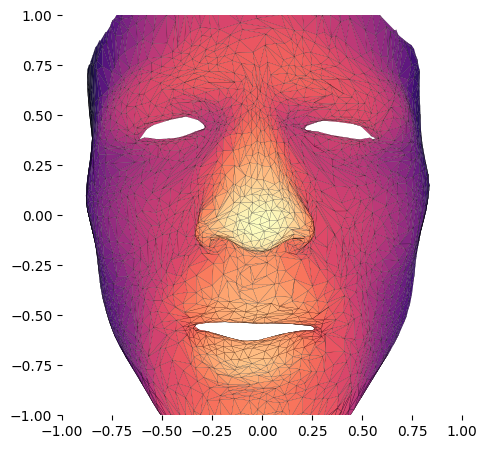

In [13]:
# _std = np.load("../utils/biwi/standardization.npy", allow_pickle=True).item()
with open("/data/sihun/BIWI_align_deci/templates_align_deci.pkl",'rb') as f:
    asd_f = pickle.load(f)
faces = asd_f['face']

pca_holder = PCA_holder(
#     '/data/sihun/BIWI_align_deci/train/vertices_npy/F3_pca.npz',
    '/data/sihun/BIWI_align_deci/train/vertices_npy/M5_pca.npz'    
)

asd = pca_holder.sample_from_pca(scale=1.0)
faces = asd_f['face']
# faces = _std['new_f']

# print()
V = normalize_homogeneous(asd)
print(asd.min(0), asd.max(0))
# V = V @ align_mat.T


model = yrotate(0)
view  = translate(0, 0, -3.5)
proj  = perspective(25, 1, 1, 100)
MVP   = proj @ view @ model
V = V @ MVP.T
V /= V[:, 3].reshape(-1, 1)

VF = V[faces]
T = VF[:, :, :2]
Z = -VF[:, :, 2].mean(axis=1)
Z = (Z - Z.min()) / (Z.max() - Z.min())
C = plt.get_cmap("magma")(Z)
I = np.argsort(Z)

T, C = T[I, :], C[I, :]
fig = plt.figure(figsize=(SIZE, SIZE))
ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
ax.add_collection(collection)
plt.show()

In [24]:
print(torch.rand(4,2)[:3].shape,torch.rand(4,2)[3:].shape)


torch.Size([3, 2]) torch.Size([1, 2])


In [4]:
model = Model_mk3_1(3, 512)

In [5]:
out = model(torch.rand(2,20,3))

In [12]:
asd = out[0]

In [16]:
qw, we = asd.unsqueeze(1).chunk(2)
qw.shape

torch.Size([1, 1, 512])

In [10]:
import torch.nn as nn

In [22]:
dim_list = [512, 192, 128, 64, 3]
asd = []
for i in range(len(dim_list)-1):
    MLP = nn.Sequential(
            nn.Linear(dim_list[i], dim_list[i]//2),
            nn.LeakyReLU(),
            nn.LayerNorm(dim_list[i]//2),
            nn.Linear(dim_list[i]//2, dim_list[i]//4),
            nn.LeakyReLU(),
            nn.LayerNorm(dim_list[i]//4),
            nn.Linear(dim_list[i]//4, dim_list[i+1]),
        )
    asd.append(MLP)
#     print(MLP)
linears = nn.ModuleList(asd)

In [26]:
out = torch.rand(1,12,512)
for i in range(len(linears)):
    out= linears[i](out)
out.shape

torch.Size([1, 12, 3])

In [3]:
model = Model_mk1(3+512,3,num_layer=4)

In [4]:
out = model(torch.rand(2,4,3+512))

In [21]:
torch.rand(32,3).view(1,-1,3).expand(3,-1,-1).shape

torch.Size([3, 32, 3])

In [22]:
from utils.remesh_utils import decimate_mesh_vertex

In [27]:
import trimesh

print(pca_holder.mean_.reshape(-1,3).shape, faces.shape)
tgt_mesh = trimesh.Trimesh(vertices=pca_holder.mean_.reshape(-1,3), faces=faces)
deci_mesh = decimate_mesh_vertex(tgt_mesh, num_vertex=512, tolerance=0)

(3525, 3) (6910, 3)
Decimated to 1124 faces, mesh has 580 vertices
Decimated to 1089 faces, mesh has 562 vertices
Decimated to 1063 faces, mesh has 549 vertices
Decimated to 1044 faces, mesh has 540 vertices
Decimated to 1029 faces, mesh has 532 vertices
Decimated to 1018 faces, mesh has 527 vertices
Decimated to 1010 faces, mesh has 523 vertices
Decimated to 1004 faces, mesh has 520 vertices
Decimated to 999 faces, mesh has 517 vertices
Decimated to 996 faces, mesh has 516 vertices
Decimated to 993 faces, mesh has 514 vertices
Decimated to 991 faces, mesh has 513 vertices
Decimated to 990 faces, mesh has 513 vertices
Decimated to 989 faces, mesh has 512 vertices
Output mesh has 512 vertices and 988 faces


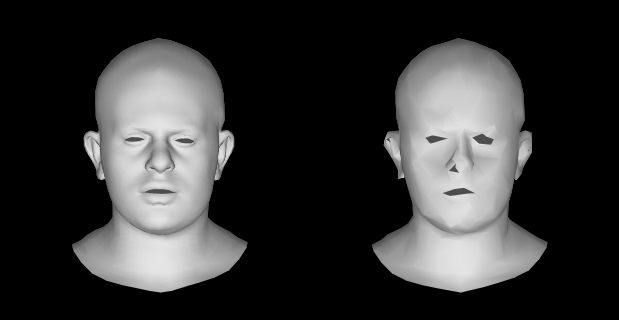

In [29]:
SIZE = 3
mesh_scale = .5

# v_list=[ src_mesh.v, new_v, control_mesh.v, control_mesh.v*1.2-control_mesh_v12_mean+control_mesh_v_mean]
v_list2=[ tgt_mesh.vertices, deci_mesh.vertices ]
f_list2=[ tgt_mesh.faces, deci_mesh.faces ]

# xyz Euler angle to rotate the mesh
rot_list=[ [10,0,0] ]*len(v_list2)


plot_mesh_gouraud(v_list2, f_list2, 
                     # is_diff=True, diff_base=src_mesh.v, #diff_revert=True,
                     mesh_scale=mesh_scale,
                     rot_list=rot_list, size=SIZE, mode='shade')

In [30]:
_=deci_mesh.export("test_cage.obj")

In [63]:
class CageNet(nn.Module):
    """
        Simple implementation of Neural Cages for Detail-preserving 3d Deformations
    """
    def __init__(self, 
                 in_dim=3,
                 hid_dim=512,
                 out_dim=3, 
                 act='relu'):
        super(CageNet, self).__init__()
        
        self.encoder = Model_mk3_1(in_dim, hid_dim)
        self.nc_decoder = Model_mk1(in_dim+hid_dim, out_dim)
        self.nd_decoder = Model_mk1(in_dim+hid_dim+hid_dim, out_dim)
        
        import trimesh
        # 512 vertices 988 faces
        test_cage=trimesh.load("../test_cage.obj")
        
        ## may need a better mesh!
        # self.template_cage_v = nn.Parameter(torch.rand(128, 3))
        self.C = test_cage.vertices.shape[0]
        self.template_cage_v = nn.Parameter(torch.tensor(test_cage.vertices).float())
        self.template_cage_f = torch.tensor(test_cage.faces).long()
        
    def forward(self, source_mesh, deform_mesh):
        """
        Args:
            source_mesh (torch.tensor) [1, N, C]: input source mesh
            deform_mesh (torch.tensor) [B, N, C]: input deformed mesh
        Return:
            predicted deformed mesh
        """
        _, V, _ = source_mesh.shape
        B, V, _ = deform_mesh.shape
        
        #shares same encoder!
        x = torch.cat([deform_mesh, source_mesh], dim=0)
        out, _ = self.encoder(x)
        out = out.unsqueeze(1)
        
        # [B, 1, 512]
        #t_code, s_code = out.unsqueeze(1).chunk(2)
        t_code, s_code = out[:B], out[B:]
        cage_v = self.template_cage_v.view(1, -1, 3)
        
        
        x_nc = torch.cat([
            s_code.expand(-1, self.C, -1), 
            cage_v
        ],dim=-1)
        source_cage_v = self.nc_decoder(x_nc)
        source_cage_v_expand = source_cage_v.expand(B, -1, -1)
        
        
        x_nd = torch.cat([
            s_code.expand(B, self.C, -1),
            t_code.expand(-1, self.C, -1),
            source_cage_v_expand
        ],dim=-1)
        deform_cage_v = self.nd_decoder(x_nd)
        
        mvc = compute_MVC(
            source_mesh.squeeze(0), 
            source_cage_v.squeeze(0), 
            self.template_cage_f
        )
        
        predicted_mesh = apply_MVC_weights_batch(
            mvc,
            self.template_cage_f,
            deform_cage_v
        )
        
        return predicted_mesh

In [64]:
mm = CageNet()

In [65]:
o = mm(torch.rand(1,5,3), torch.rand(2,5,3))

torch.Size([5, 3]) torch.Size([512, 3]) torch.Size([988, 3])


In [66]:
o.shape

torch.Size([2, 5, 3])